# Modelo XGBoost — AirPrice

Este notebook implementa y evalúa el modelo XGBoost para la clasificación del rango de precio de alojamientos Airbnb.

Se utiliza el preprocesamiento compartido del proyecto dentro de un `Pipeline`, manteniendo la misma semilla y división estratificada definida para todos los modelos.

In [3]:
import sys
sys.path.append("../..")

In [4]:
from src.preprocessing import (
    construir_X_y,
    descartar_columnas,
)

from src.utils import (
    CLASES,
    SEED,
    cargar_dataset,
    evaluar_modelo,
    fijar_semilla,
    guardar_modelo,
    split_estratificado,
)

from src.model_xgboost import construir_modelo_xgboost

In [5]:
fijar_semilla(SEED)

print("Semilla utilizada:", SEED)

Semilla utilizada: 42


In [6]:
df = cargar_dataset()

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 61617
Columnas: 32


In [7]:
X, y = construir_X_y(df)

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

print("\nDistribución del target:")
print(y.value_counts())

Dimensión de X: (61617, 22)
Dimensión de y: (61617,)

Distribución del target:
price_range
ECONOMICO    15491
PREMIUM      15398
ALTO         15368
MEDIO        15360
Name: count, dtype: int64


In [8]:
print("price_clean en X:", "price_clean" in X.columns)
print("price_range en X:", "price_range" in X.columns)
print("id en X:", "id" in X.columns)

price_clean en X: False
price_range en X: False
id en X: False


In [9]:
df_modelo = descartar_columnas(df)

In [10]:
X_train, X_val, X_test, y_train, y_val, y_test = split_estratificado(
    df_modelo,
    target="price_range",
    excluir=[
        "price_clean",
        "id",
    ],
    seed=SEED,
)

In [11]:
print("Train:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (43131, 22) (43131,)
Validación: (9243, 22) (9243,)
Test: (9243, 22) (9243,)


In [12]:
print("Clases:", y_train.unique())
print("Tipo:", y_train.dtype)

Clases: <StringArray>
['MEDIO', 'PREMIUM', 'ECONOMICO', 'ALTO']
Length: 4, dtype: str
Tipo: str


## 2. Codificación de la variable objetivo

XGBoost requiere clases numéricas para el entrenamiento. Se conserva el orden natural de los rangos de precio definido por el proyecto.

In [13]:
MAPEO_CLASES = {
    "ECONOMICO": 0,
    "MEDIO": 1,
    "ALTO": 2,
    "PREMIUM": 3,
}

MAPEO_INVERSO = {
    valor: clase
    for clase, valor in MAPEO_CLASES.items()
}

y_train_encoded = y_train.map(MAPEO_CLASES).astype(int)
y_val_encoded = y_val.map(MAPEO_CLASES).astype(int)
y_test_encoded = y_test.map(MAPEO_CLASES).astype(int)

print("Clases originales:")
print(y_train.unique())

print("\nClases codificadas:")
print(sorted(y_train_encoded.unique()))

Clases originales:
<StringArray>
['MEDIO', 'PREMIUM', 'ECONOMICO', 'ALTO']
Length: 4, dtype: str

Clases codificadas:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [14]:
print("NaN train:", y_train_encoded.isna().sum())
print("NaN validación:", y_val_encoded.isna().sum())
print("NaN test:", y_test_encoded.isna().sum())

NaN train: 0
NaN validación: 0
NaN test: 0


## 3. Modelo XGBoost base

Se construye un Pipeline compuesto por el preprocesador común del proyecto y `XGBClassifier`.

El preprocesamiento se ajusta exclusivamente con los datos de entrenamiento, evitando fuga de información. Para XGBoost no se aplica escalado a las variables numéricas.

In [15]:
modelo_xgb = construir_modelo_xgboost(
    X_train,
    learning_rate=0.1,
)

modelo_xgb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

In [16]:
modelo_xgb.fit(
    X_train,
    y_train_encoded,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](4,)","[0,1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['neighbourhood_cleansed','latitude','longitude',...,'bedrooms_missing', 'beds_missing','minimum_nights_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``)

In [17]:
y_val_pred_encoded = modelo_xgb.predict(X_val)

y_val_pred = [
    MAPEO_INVERSO[int(valor)]
    for valor in y_val_pred_encoded
]


In [18]:
print(y_val_pred[:10])

['ALTO', 'ALTO', 'ALTO', 'ALTO', 'ECONOMICO', 'MEDIO', 'PREMIUM', 'ECONOMICO', 'ECONOMICO', 'PREMIUM']


In [19]:
metricas_base = evaluar_modelo(
    y_val,
    y_val_pred,
    etiquetas=CLASES,
)

metricas_base

{'accuracy': 0.6747809152872444,
 'balanced_accuracy': 0.6743730889363838,
 'f1_macro': 0.6720168016987591,
 'f1_weighted': 0.6723506230983225,
 'matriz_confusion': array([[1964,  308,   40,   12],
        [ 489, 1201,  562,   52],
        [  77,  448, 1342,  438],
        [  29,   98,  453, 1730]])}

In [20]:
print("Accuracy:", metricas_base["accuracy"])
print("Balanced Accuracy:", metricas_base["balanced_accuracy"])
print("F1-Macro:", metricas_base["f1_macro"])
print("F1-Weighted:", metricas_base["f1_weighted"])

print("\nMatriz de confusión:")
print(metricas_base["matriz_confusion"])

Accuracy: 0.6747809152872444
Balanced Accuracy: 0.6743730889363838
F1-Macro: 0.6720168016987591
F1-Weighted: 0.6723506230983225

Matriz de confusión:
[[1964  308   40   12]
 [ 489 1201  562   52]
 [  77  448 1342  438]
 [  29   98  453 1730]]


In [22]:
metricas_base = evaluar_modelo(
    y_val,
    y_val_pred,
    etiquetas=CLASES,
)

### Resultados del modelo base

El modelo XGBoost base obtuvo un F1-Macro de aproximadamente **0.672**, un F1-Weighted de **0.672** y una Balanced Accuracy de **0.674** sobre el conjunto de validación.

La similitud entre F1-Macro y F1-Weighted indica que el rendimiento es relativamente equilibrado entre las cuatro clases.

La matriz de confusión muestra un mejor reconocimiento de las clases extremas `ECONOMICO` y `PREMIUM`, mientras que existe una mayor confusión entre las clases adyacentes `MEDIO` y `ALTO`. Este comportamiento es coherente con la naturaleza ordinal del problema, ya que los rangos de precio cercanos pueden presentar características similares.

Estos resultados se utilizarán como línea base para evaluar el efecto de la optimización del hiperparámetro `learning_rate`.

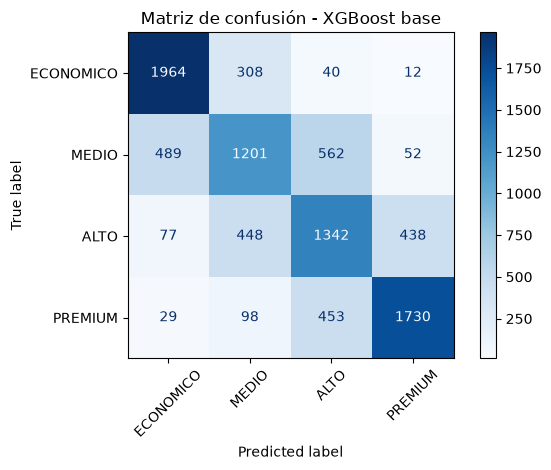

Figura guardada en: ..\..\reports\xgboost_base_matriz_confusion.png


In [23]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

REPORTS_DIR = Path("../../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

disp = ConfusionMatrixDisplay(
    confusion_matrix=metricas_base["matriz_confusion"],
    display_labels=CLASES,
)

disp.plot(
    cmap="Blues",
    values_format="d",
)

plt.title("Matriz de confusión - XGBoost base")
plt.xticks(rotation=45)
plt.tight_layout()

ruta_figura = REPORTS_DIR / "xgboost_base_matriz_confusion.png"
plt.savefig(ruta_figura, dpi=150, bbox_inches="tight")
plt.show()

print("Figura guardada en:", ruta_figura)

In [25]:
import pandas as pd

In [26]:
metricas_base_df = pd.DataFrame(
    [{
        "modelo": "xgboost_base",
        "learning_rate": 0.1,
        "accuracy": metricas_base["accuracy"],
        "balanced_accuracy": metricas_base["balanced_accuracy"],
        "f1_macro": metricas_base["f1_macro"],
        "f1_weighted": metricas_base["f1_weighted"],
    }]
)

ruta_metricas = REPORTS_DIR / "xgboost_base_metricas.csv"
metricas_base_df.to_csv(ruta_metricas, index=False)

metricas_base_df

,modelo,learning_rate,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,xgboost_base,0.1,0.674781,0.674373,0.672017,0.672351


In [27]:
ruta_modelo = guardar_modelo(
    modelo_xgb,
    "xgboost",
)

print("Modelo guardado en:", ruta_modelo)

Modelo guardado en: C:\Users\danna\AirPrice\models\xgboost.joblib


## 4. Optimización de learning_rate

Se evalúan distintos valores de `learning_rate` manteniendo constantes los demás hiperparámetros del modelo.

La selección se realiza sobre el conjunto de validación utilizando F1-Macro, F1-Weighted y Balanced Accuracy.

In [28]:
learning_rates = [
    0.01,
    0.05,
    0.10,
]

In [29]:
resultados_lr = []

for lr in learning_rates:
    print(f"Entrenando learning_rate={lr}")

    modelo = construir_modelo_xgboost(
        X_train,
        learning_rate=lr,
    )

    modelo.fit(
        X_train,
        y_train_encoded,
    )

    y_pred_encoded = modelo.predict(X_val)

    y_pred = [
        MAPEO_INVERSO[int(valor)]
        for valor in y_pred_encoded
    ]

    metricas = evaluar_modelo(
        y_val,
        y_pred,
        etiquetas=CLASES,
    )

    resultados_lr.append(
        {
            "learning_rate": lr,
            "accuracy": metricas["accuracy"],
            "balanced_accuracy": metricas["balanced_accuracy"],
            "f1_macro": metricas["f1_macro"],
            "f1_weighted": metricas["f1_weighted"],
        }
    )

Entrenando learning_rate=0.01
Entrenando learning_rate=0.05
Entrenando learning_rate=0.1


In [32]:
resultados_lr_df = pd.DataFrame(
    resultados_lr
)

resultados_lr_df

,learning_rate,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,0.01,0.625230,0.624726,0.619955,0.620341
1,0.05,0.658011,0.657556,0.653335,0.653683
2,0.10,0.674781,0.674373,0.672017,0.672351


In [33]:
resultados_lr_df.sort_values(
    by="f1_macro",
    ascending=False,
)

,learning_rate,accuracy,balanced_accuracy,f1_macro,f1_weighted
2,0.10,0.674781,0.674373,0.672017,0.672351
1,0.05,0.658011,0.657556,0.653335,0.653683
0,0.01,0.625230,0.624726,0.619955,0.620341


In [34]:
mejor_fila = resultados_lr_df.loc[
    resultados_lr_df["f1_macro"].idxmax()
]

mejor_learning_rate = mejor_fila["learning_rate"]

print(
    "Mejor learning_rate:",
    mejor_learning_rate,
)

print(
    "F1-Macro:",
    mejor_fila["f1_macro"],
)

print(
    "Balanced Accuracy:",
    mejor_fila["balanced_accuracy"],
)

Mejor learning_rate: 0.1
F1-Macro: 0.6720168016987591
Balanced Accuracy: 0.6743730889363838


In [35]:
ruta_resultados_lr = (
    REPORTS_DIR
    / "xgboost_learning_rate_comparacion.csv"
)

resultados_lr_df.to_csv(
    ruta_resultados_lr,
    index=False,
)

print(
    "Resultados guardados en:",
    ruta_resultados_lr,
)

Resultados guardados en: ..\..\reports\xgboost_learning_rate_comparacion.csv


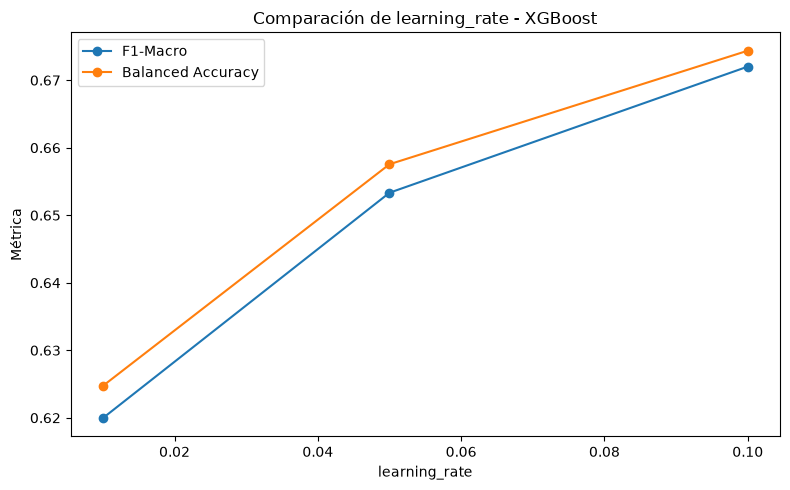

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_lr_df["learning_rate"],
    resultados_lr_df["f1_macro"],
    marker="o",
    label="F1-Macro",
)

plt.plot(
    resultados_lr_df["learning_rate"],
    resultados_lr_df["balanced_accuracy"],
    marker="o",
    label="Balanced Accuracy",
)

plt.xlabel("learning_rate")
plt.ylabel("Métrica")
plt.title("Comparación de learning_rate - XGBoost")
plt.legend()
plt.tight_layout()

ruta_figura_lr = (
    REPORTS_DIR
    / "xgboost_learning_rate_comparacion.png"
)

plt.savefig(
    ruta_figura_lr,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [37]:
mejor_modelo_xgb = construir_modelo_xgboost(
    X_train,
    learning_rate=float(
        mejor_learning_rate
    ),
)

In [38]:
mejor_modelo_xgb.fit(
    X_train,
    y_train_encoded,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](4,)","[0,1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['neighbourhood_cleansed','latitude','longitude',...,'bedrooms_missing', 'beds_missing','minimum_nights_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``)

In [39]:
y_val_pred_final_encoded = (
    mejor_modelo_xgb.predict(
        X_val
    )
)

y_val_pred_final = [
    MAPEO_INVERSO[int(valor)]
    for valor
    in y_val_pred_final_encoded
]

metricas_final_val = evaluar_modelo(
    y_val,
    y_val_pred_final,
    etiquetas=CLASES,
)

metricas_final_val

{'accuracy': 0.6747809152872444,
 'balanced_accuracy': 0.6743730889363838,
 'f1_macro': 0.6720168016987591,
 'f1_weighted': 0.6723506230983225,
 'matriz_confusion': array([[1964,  308,   40,   12],
        [ 489, 1201,  562,   52],
        [  77,  448, 1342,  438],
        [  29,   98,  453, 1730]])}

In [40]:
ruta_modelo_final = guardar_modelo(
    mejor_modelo_xgb,
    "xgboost",
)

print(
    "Modelo final guardado en:",
    ruta_modelo_final,
)

Modelo final guardado en: C:\Users\danna\AirPrice\models\xgboost.joblib


### Selección de learning_rate

Se evaluaron los valores `0.01`, `0.05` y `0.10` para el hiperparámetro `learning_rate`, manteniendo constantes los demás parámetros del modelo.

El mejor desempeño sobre el conjunto de validación se obtuvo con `learning_rate = 0.10`, alcanzando:

- Accuracy: **0.6748**
- Balanced Accuracy: **0.6744**
- F1-Macro: **0.6720**
- F1-Weighted: **0.6724**

Los resultados muestran una mejora progresiva del desempeño al incrementar el `learning_rate` dentro de los valores evaluados. Por esta razón, se selecciona `0.10` como configuración final entre las alternativas probadas.

In [42]:
ruta_resultados_lr = (
    REPORTS_DIR
    / "xgboost_learning_rate_comparacion.csv"
)

resultados_lr_df.to_csv(
    ruta_resultados_lr,
    index=False,
)

print("Guardado en:", ruta_resultados_lr)

Guardado en: ..\..\reports\xgboost_learning_rate_comparacion.csv


In [43]:
mejor_learning_rate = 0.10

mejor_modelo_xgb = construir_modelo_xgboost(
    X_train,
    learning_rate=mejor_learning_rate,
)

mejor_modelo_xgb.fit(
    X_train,
    y_train_encoded,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](4,)","[0,1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['neighbourhood_cleansed','latitude','longitude',...,'bedrooms_missing', 'beds_missing','minimum_nights_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``)

In [44]:
y_test_pred_encoded = mejor_modelo_xgb.predict(
    X_test
)

y_test_pred = [
    MAPEO_INVERSO[int(valor)]
    for valor in y_test_pred_encoded
]

metricas_test = evaluar_modelo(
    y_test,
    y_test_pred,
    etiquetas=CLASES,
)

In [45]:
print(
    "Accuracy:",
    metricas_test["accuracy"],
)

print(
    "Balanced Accuracy:",
    metricas_test["balanced_accuracy"],
)

print(
    "F1-Macro:",
    metricas_test["f1_macro"],
)

print(
    "F1-Weighted:",
    metricas_test["f1_weighted"],
)

print("\nMatriz de confusión:")
print(
    metricas_test["matriz_confusion"]
)

Accuracy: 0.6711024559125824
Balanced Accuracy: 0.6707304390368845
F1-Macro: 0.6685481208783667
F1-Weighted: 0.6688458309666926

Matriz de confusión:
[[1949  324   38   12]
 [ 514 1184  558   48]
 [  76  441 1368  421]
 [  42   96  470 1702]]


In [46]:
metricas_test_df = pd.DataFrame(
    [{
        "modelo": "xgboost",
        "learning_rate": mejor_learning_rate,
        "accuracy": metricas_test["accuracy"],
        "balanced_accuracy": metricas_test[
            "balanced_accuracy"
        ],
        "f1_macro": metricas_test["f1_macro"],
        "f1_weighted": metricas_test[
            "f1_weighted"
        ],
    }]
)

ruta_metricas_test = (
    REPORTS_DIR
    / "xgboost_metricas_test.csv"
)

metricas_test_df.to_csv(
    ruta_metricas_test,
    index=False,
)

metricas_test_df

,modelo,learning_rate,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,xgboost,0.1,0.671102,0.67073,0.668548,0.668846


## Conclusión del modelo XGBoost

El modelo XGBoost fue entrenado utilizando el pipeline común del proyecto, con el preprocesamiento ajustado únicamente sobre los datos de entrenamiento y sin aplicar escalado a las variables numéricas.

Durante la optimización del hiperparámetro `learning_rate` se evaluaron los valores `0.01`, `0.05` y `0.10`. El mejor desempeño sobre el conjunto de validación se obtuvo con `learning_rate = 0.10`.

Con esta configuración, el modelo fue evaluado finalmente sobre el conjunto de prueba, obteniendo:

- Accuracy: **0.6711**
- Balanced Accuracy: **0.6707**
- F1-Macro: **0.6685**
- F1-Weighted: **0.6688**

Los resultados del conjunto de prueba son cercanos a los obtenidos durante la validación, lo que indica un comportamiento consistente del modelo sobre datos no utilizados para la selección del hiperparámetro.

El modelo final fue almacenado como `xgboost` mediante la función común `guardar_modelo()`, y sus métricas y figuras fueron registradas en `reports/` para su posterior comparación con los demás modelos del proyecto.